# Résultats du modèle de maintenance prédictive thermique FTTH

**Objectif** : prédire, heure par heure, la probabilité qu'un OLT tombe (incident thermique grave : `HITEMP`, `TMPH`, `MULTIFANFAILURE`, `SHUTDOWN`) dans les **6 prochaines heures**.

Ce notebook produit les figures et tableaux à insérer dans le mémoire :
1. Statistiques du dataset
2. Courbe ROC et courbe Précision/Rappel (validation croisée par site)
3. Matrice de confusion
4. Importance des variables
5. Backtest leave-one-site-out (SEGBE-FX4)
6. Classement actuel des OLT à risque

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path.cwd()
sys.path.insert(0, str(BASE / 'src'))

from features import FEATURE_COLUMNS
from train_model import make_model, sample_weights, usable_features

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200

ds = pd.read_pickle(BASE / 'data' / 'dataset.pkl')
bundle = joblib.load(BASE / 'models' / 'thermal_model.joblib')
metrics = json.loads((BASE / 'models' / 'metrics.json').read_text())
FIG = BASE / 'figures'
FIG.mkdir(exist_ok=True)
print(f"Dataset : {len(ds):,} heures-OLT | {ds['site'].nunique()} sites | positifs : {int(ds['target'].sum())}")

Dataset : 112,633 heures-OLT | 144 sites | positifs : 68


## 1. Statistiques du dataset

In [2]:
stats = pd.DataFrame({
    'Indicateur': [
        'Heures-OLT (lignes)', 'Sites OLT', 'Variables (features)',
        'Positifs (chute sous 6h)', 'Taux de positifs',
        'Période couverte',
    ],
    'Valeur': [
        f"{len(ds):,}", ds['site'].nunique(), len(FEATURE_COLUMNS),
        int(ds['target'].sum()), f"{100*ds['target'].mean():.3f} %",
        f"{ds['hour_ts'].min():%d/%m/%Y} → {ds['hour_ts'].max():%d/%m/%Y}",
    ],
})
stats

,Indicateur,Valeur
0,Heures-OLT (lignes),"112,633"
1,Sites OLT,144
2,Variables (features),39
3,Positifs (chute sous 6h),68
4,Taux de positifs,0.060 %
5,Période couverte,01/04/2026 → 22/06/2026


## 2. Validation croisée par site (out-of-fold)
Le modèle est évalué uniquement sur des OLT **jamais vus à l'entraînement** (`StratifiedGroupKFold`, 5 blocs).

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

X_all = ds[FEATURE_COLUMNS]
feats = usable_features(X_all)
X, y, groups = ds[feats], ds['target'], ds['site']

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(ds))
for i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    m = make_model()
    m.fit(X.iloc[tr], y.iloc[tr], sample_weight=sample_weights(y.iloc[tr]))
    oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    print(f'  bloc {i}/5 terminé')
print('Validation croisée terminée.')

[train] colonnes constantes ignorees : margin_shutdown_min, margin_tca_min, n_sensors, temp_max


  bloc 1/5 terminé


  bloc 2/5 terminé


  bloc 3/5 terminé


  bloc 4/5 terminé


  bloc 5/5 terminé
Validation croisée terminée.


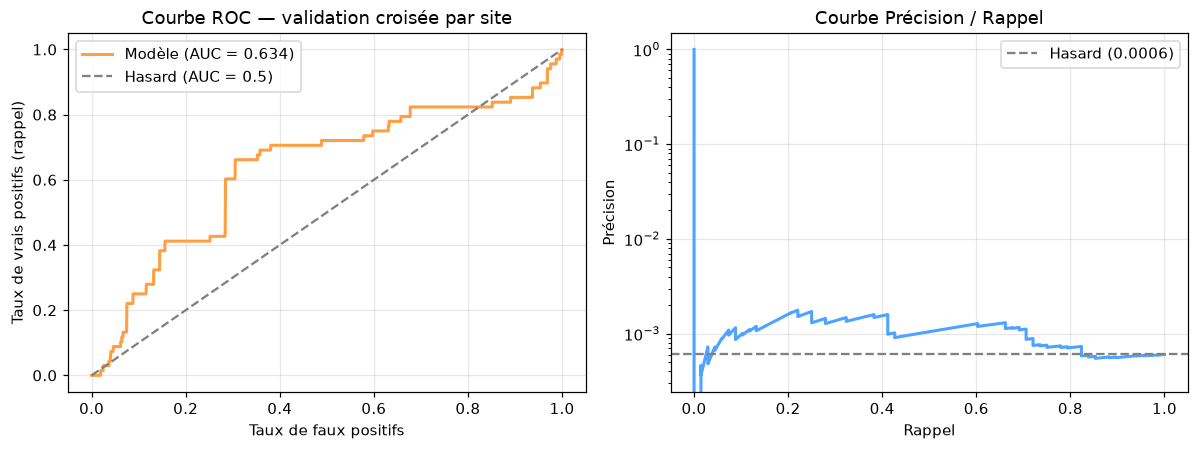

In [4]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y, oof)
prec, rec, thr = precision_recall_curve(y, oof)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(fpr, tpr, color='#ff9f43', lw=2,
             label=f'Modèle (AUC = {roc_auc_score(y, oof):.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='grey', label='Hasard (AUC = 0.5)')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs (rappel)')
axes[0].set_title('Courbe ROC — validation croisée par site')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(rec, prec, color='#4da3ff', lw=2)
axes[1].axhline(y.mean(), ls='--', color='grey',
                label=f'Hasard ({y.mean():.4f})')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Précision / Rappel')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(FIG / 'fig_roc_pr.png', bbox_inches='tight')
plt.show()

## 3. Matrice de confusion (au seuil optimisé F1)

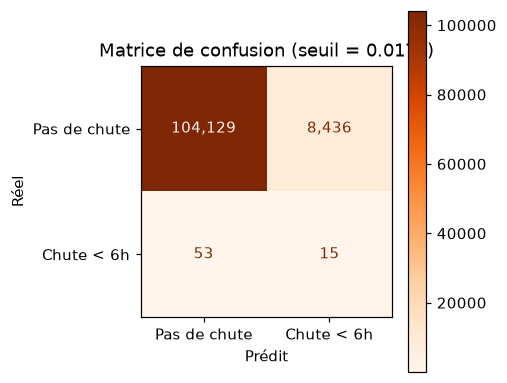

Rappel (chutes détectées)      : 22.1%
Spécificité (calme bien classé): 92.5%


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
seuil = thr[int(np.nanargmax(f1[:-1]))]
y_pred = (oof >= seuil).astype(int)
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Pas de chute', 'Chute < 6h']).plot(
    ax=ax, cmap='Oranges', values_format=','
)
ax.set_title(f'Matrice de confusion (seuil = {seuil:.4f})')
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
plt.tight_layout()
plt.savefig(FIG / 'fig_confusion.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Rappel (chutes détectées)      : {tp/(tp+fn):.1%}')
print(f'Spécificité (calme bien classé): {tn/(tn+fp):.1%}')

## 4. Importance des variables (permutation)

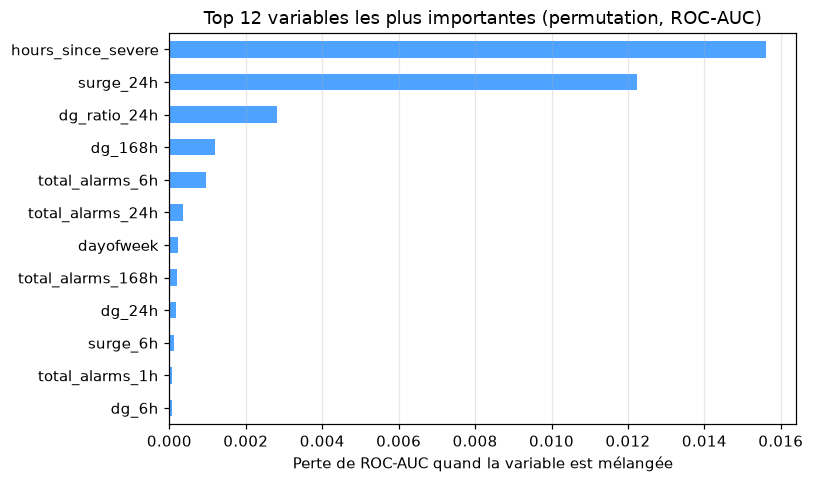

In [6]:
from sklearn.inspection import permutation_importance

# échantillon stratifié pour un calcul rapide
pos = ds[ds['target'] == 1]
neg = ds[ds['target'] == 0].sample(20000, random_state=42)
sample = pd.concat([pos, neg])

model = bundle['model']
imp = permutation_importance(
    model, sample[bundle['features']], sample['target'],
    scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
)
top = (pd.Series(imp.importances_mean, index=bundle['features'])
       .sort_values().tail(12))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
top.plot.barh(ax=ax, color='#4da3ff')
ax.set_title('Top 12 variables les plus importantes (permutation, ROC-AUC)')
ax.set_xlabel('Perte de ROC-AUC quand la variable est mélangée')
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.savefig(FIG / 'fig_importance.png', bbox_inches='tight')
plt.show()

## 5. Backtest leave-one-site-out : SEGBE-FX4
L'OLT est **entièrement retiré** de l'entraînement, puis sa chronologie est rejouée heure par heure.
La chute réelle (HITEMP) a eu lieu le **29/04/2026 à 09h33**.

[train] colonnes constantes ignorees : margin_shutdown_min, margin_tca_min, n_sensors, temp_max


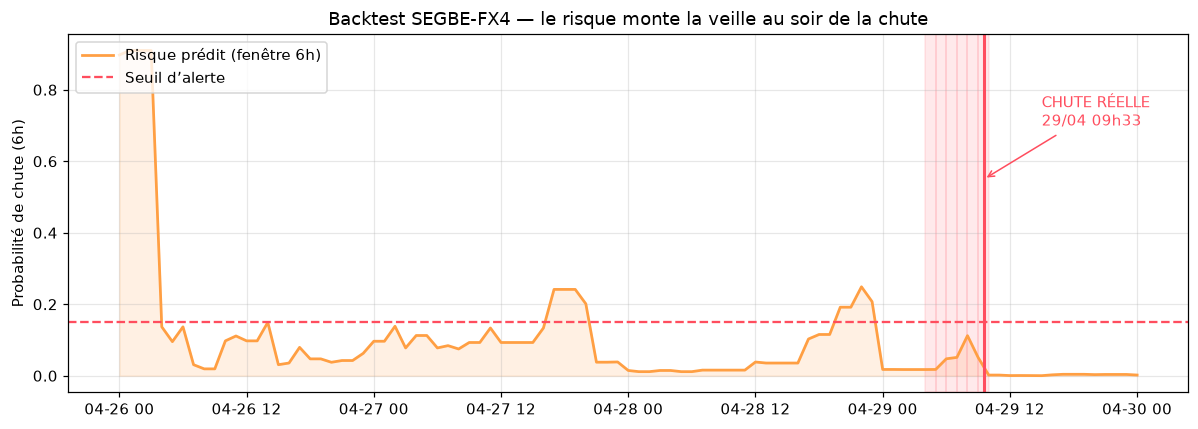

Fausses alertes (heures calmes, seuil 0.15) : 4.5%


In [7]:
SITE = 'SEGBE-FX4'
train = ds[ds['site'] != SITE]
feats_bt = usable_features(train[FEATURE_COLUMNS])
m = make_model()
m.fit(train[feats_bt], train['target'], sample_weight=sample_weights(train['target']))

site_df = ds[ds['site'] == SITE].sort_values('hour_ts').copy()
site_df['risque'] = m.predict_proba(site_df[feats_bt])[:, 1]

w = site_df[(site_df['hour_ts'] >= '2026-04-26') & (site_df['hour_ts'] <= '2026-04-30')]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(w['hour_ts'], w['risque'], color='#ff9f43', lw=1.8, label='Risque prédit (fenêtre 6h)')
ax.fill_between(w['hour_ts'], w['risque'], color='#ff9f43', alpha=.15)
ax.axhline(0.15, ls='--', color='#ff4d5e', label='Seuil d’alerte')
for t in w.loc[w['target'] == 1, 'hour_ts']:
    ax.axvspan(t, t + pd.Timedelta(hours=1), color='#ff4d5e', alpha=.12)
ax.axvline(pd.Timestamp('2026-04-29 09:33'), color='#ff4d5e', lw=2)
ax.annotate('CHUTE RÉELLE\n29/04 09h33', xy=(pd.Timestamp('2026-04-29 09:33'), .55),
            xytext=(pd.Timestamp('2026-04-29 15:00'), .7), color='#ff4d5e',
            arrowprops=dict(arrowstyle='->', color='#ff4d5e'))
ax.set_title(f'Backtest {SITE} — le risque monte la veille au soir de la chute')
ax.set_ylabel('Probabilité de chute (6h)')
ax.legend(loc='upper left')
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG / 'fig_backtest_segbe.png', bbox_inches='tight')
plt.show()

calm = site_df[site_df['target'] == 0]
print(f"Fausses alertes (heures calmes, seuil 0.15) : {(calm['risque'] >= 0.15).mean():.1%}")

## 6. Classement actuel des OLT à risque

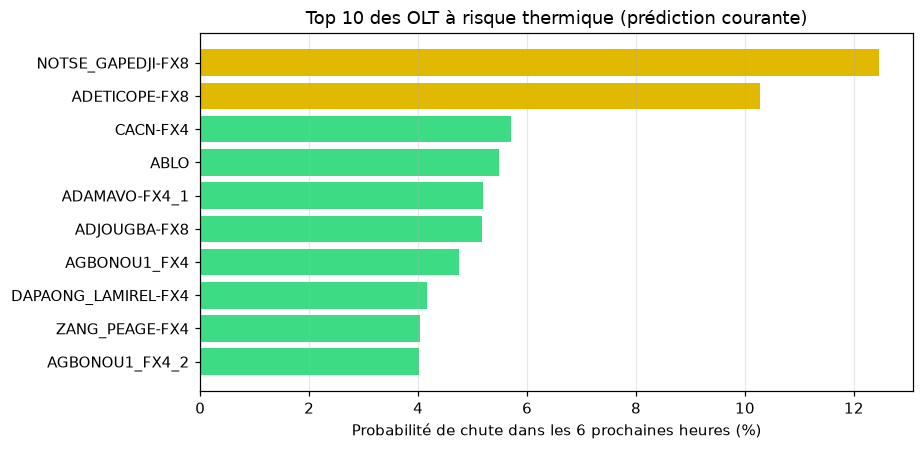

,site,risk_proba,risk_level,fan_alarms_24h,severe_168h
0,NOTSE_GAPEDJI-FX8,0.124613,SURVEILLANCE,0.0,0.0
1,ADETICOPE-FX8,0.102815,SURVEILLANCE,0.0,0.0
2,CACN-FX4,0.056983,NORMAL,0.0,0.0
3,ABLO,0.054801,NORMAL,0.0,0.0
4,ADAMAVO-FX4_1,0.051973,NORMAL,0.0,0.0
5,ADJOUGBA-FX8,0.051697,NORMAL,0.0,0.0
6,AGBONOU1_FX4,0.047408,NORMAL,0.0,0.0
7,DAPAONG_LAMIREL-FX4,0.041630,NORMAL,0.0,0.0
8,ZANG_PEAGE-FX4,0.040410,NORMAL,0.0,0.0
9,AGBONOU1_FX4_2,0.040212,NORMAL,0.0,0.0


In [8]:
preds = json.loads((BASE / 'data' / 'predictions.json').read_text())
top10 = pd.DataFrame(preds['sites']).head(10)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = top10['risk_level'].map({'CRITIQUE': '#ff4d5e', 'ELEVE': '#ff9f43',
                                   'SURVEILLANCE': '#e0b900', 'NORMAL': '#3ddc84'})
ax.barh(top10['site'][::-1], top10['risk_proba'][::-1] * 100, color=colors[::-1])
ax.set_xlabel('Probabilité de chute dans les 6 prochaines heures (%)')
ax.set_title('Top 10 des OLT à risque thermique (prédiction courante)')
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.savefig(FIG / 'fig_top_sites.png', bbox_inches='tight')
plt.show()

top10[['site', 'risk_proba', 'risk_level', 'fan_alarms_24h', 'severe_168h']]

---
**Les 4 figures sont enregistrées dans le dossier `figures/`** (200 dpi, prêtes à insérer dans le mémoire) :
- `fig_roc_pr.png` — courbes ROC et Précision/Rappel
- `fig_confusion.png` — matrice de confusion
- `fig_importance.png` — importance des variables
- `fig_backtest_segbe.png` — backtest SEGBE-FX4 (la figure clé de la soutenance)
- `fig_top_sites.png` — classement actuel des OLT